# Проект: Исследование стартапов

## Введение

Финансовая компания рассматривает возможность выхода на рынок инвестиций в стартапы через их покупку, развитие и последующую продажу. Для этого важно изучить исторические данные о сделках и характеристиках стартапов, чтобы понять, какие факторы могут влиять на успешность таких вложений.  

**Цель проекта** — проверить качество и полноту данных, выявить закономерности и ответить на ключевые вопросы:  

- по каким признакам можно объединять данные из разных таблиц;  
- насколько можно доверять информации о сотрудниках и их образовании;  
- что означают сделки с ценой 0 или 1 доллар;  
- как связаны категории стартапов и количество раундов финансирования с ценой покупки;  
- какие показатели помогают оценивать вероятность успешной сделки.  

Результаты анализа позволят выявить полезные признаки и дать рекомендации для будущей стратегии работы со стартапами.


## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Опциональные датасеты:
* fund.csv
* investment.csv

### 1.1. Вывод общей информации, исправление названия столбцов

In [1]:
# Импортируем нужные библиотеки
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Загружаем датасеты
acquisition = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
company_and_rounds = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
degrees = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')

In [3]:
# Опциональные датасеты (если понадобятся на следующих шагах)
fund = pd.read_csv('https://code.s3.yandex.net/datasets/fund.csv')
investment = pd.read_csv('https://code.s3.yandex.net/datasets/investment.csv')

In [4]:
# Проверим первые строки и названия столбцов
datasets = {
    "acquisition": acquisition,
    "company_and_rounds": company_and_rounds,
    "people": people,
    "education": education,
    "degrees": degrees
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.info())
    display(df.head())


ACQUISITION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB
None


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01



COMPANY_AND_ROUNDS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id     

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



PEOPLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB
None


,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN



EDUCATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB
None


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN



DEGREES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB
None


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


In [5]:
def clean_columns(df, table_name=None):
    """
    Приводим названия колонок к удобному виду:
    - убираем пробелы
    - заменяем пробелы на "_"
    - приводим к нижнему регистру
    - устраняем дубликаты колонок
    """
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r'\s+', '_', regex=True)
        .str.lower()
    )

    # Проверка на дубликаты после очистки
    if df.columns.duplicated().any():
        cols = []
        seen = {}
        for col in df.columns:
            if col not in seen:
                seen[col] = 0
                cols.append(col)
            else:
                seen[col] += 1
                cols.append(f"{col}_{seen[col]}")  # добавляем индекс
        df.columns = cols

    # Специальная доработка для company_and_rounds
    if table_name == "company_and_rounds":
        df = df.rename(
            columns={
                "company_id": "company_id_main",   # основной id
                "company_id_1": "company_id_round" # id для раундов
            }
        )

    return df


# применяем функцию
acquisition = clean_columns(acquisition, "acquisition")
company_and_rounds = clean_columns(company_and_rounds, "company_and_rounds")
people = clean_columns(people, "people")
education = clean_columns(education, "education")
degrees = clean_columns(degrees, "degrees")

# проверим результат
print(company_and_rounds.columns)

Index(['company_id_main', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id_round', 'funded_at',
       'funding_round_type', 'raised_amount', 'pre_money_valuation',
       'participants', 'is_first_round', 'is_last_round'],
      dtype='object')


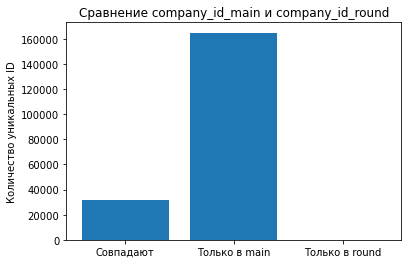

Совпадающих company_id: 31707
Только в company_id_main: 164846
Только в company_id_round: 232


In [6]:
first_id = set(company_and_rounds['company_id_main'].dropna().unique())
second_id = set(company_and_rounds['company_id_round'].dropna().unique())

intersection = len(first_id & second_id)
only_main = len(first_id - second_id)
only_round = len(second_id - first_id)

# Столбчатая диаграмма
plt.bar(["Совпадают", "Только в main", "Только в round"],
        [intersection, only_main, only_round])
plt.title("Сравнение company_id_main и company_id_round")
plt.ylabel("Количество уникальных ID")
plt.show()

print("Совпадающих company_id:", intersection)
print("Только в company_id_main:", only_main)
print("Только в company_id_round:", only_round)

In [7]:
# Проверим дополнительно, что стоит за 232 company_id_round

# находим те id, которых нет в основном списке
orphan_ids = second_id - first_id
print(len(orphan_ids))  # должно быть 232
list(orphan_ids)[:20]   # посмотрим первые 20

232


[2051.0,
 5636.0,
 1029.0,
 1031.0,
 31751.0,
 82953.0,
 230921.0,
 8717.0,
 54800.0,
 42514.0,
 7190.0,
 284191.0,
 11808.0,
 75295.0,
 32810.0,
 38956.0,
 558.0,
 1073.0,
 152123.0,
 1086.0]

In [8]:
# Посмотрим строки
company_and_rounds[company_and_rounds['company_id_round'].isin(orphan_ids)].head(10)

,company_id_main,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id_round,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
217472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,457.0,1267.0,2005-01-01,series-a,48000000.0,0.0,2.0,1.0,1.0
217473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,471.0,558.0,2007-01-01,angel,300000.0,0.0,1.0,1.0,1.0
217474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,575.0,746.0,2004-09-01,angel,0.0,0.0,0.0,1.0,1.0
217475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,577.0,748.0,2007-01-01,series-a,1500000.0,2250000.0,0.0,1.0,1.0
217476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,597.0,804.0,2007-06-01,series-a,6000000.0,0.0,2.0,1.0,1.0
217477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,649.0,887.0,2006-07-01,series-a,25000000.0,6000000.0,1.0,1.0,1.0
217478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1421.0,887.0,2006-07-01,series-a,2500000.0,2100000.0,1.0,1.0,1.0
217479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,655.0,901.0,2007-01-01,angel,350000.0,0.0,0.0,1.0,1.0
217480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,678.0,1519.0,2006-01-01,series-a,2100000.0,0.0,1.0,0.0,1.0
217481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1102.0,1519.0,2007-09-01,series-b,6500000.0,0.0,2.0,0.0,0.0


In [9]:
# Проверим, везде ли у них пустое company_id_main
company_and_rounds[
    company_and_rounds['company_id_round'].isin(orphan_ids) & 
    company_and_rounds['company_id_main'].isna()
].shape

(302, 22)

In [10]:
# Проверим названия компаний

missing_rounds = company_and_rounds[company_and_rounds['company_id_round'].isin(orphan_ids)]
print(missing_rounds['name'].unique()[:20])

[nan]


#### Промежуточный вывод: проверка данных и исправление названий столбцов

**Приведение названий столбцов**

- Все названия колонок приведены к единому формату: пробелы заменены на `_`, приведены к нижнему регистру.
- В `company_and_rounds` обнаружен дубликат столбца `company_id`. Исправлено:
  - `company_id_main` — основной идентификатор компании
  - `company_id_round` — идентификатор для раундов финансирования

**Типы данных**
- Даты (`founded_at`, `closed_at`, `funded_at`, `acquired_at`, `graduated_at`) приведены к типу `datetime`.
- Числовые и категориальные столбцы определены корректно.

**Особенности датасета `company_and_rounds`**
- Проверка пересечения идентификаторов:
  - Совпадают: 31 707
  - Только в `company_id_main`: 164 846
  - Только в `company_id_round`: 232 (по строкам — 302). Почему их больше 232: в company_and_rounds один company_id_round может встречаться в нескольких раундах, поэтому после фильтрации мы видим 302 строки.
- Эти 232 «висящие» раунда **не имеют информации о компании** (`company_id_main = NaN`, `name = NaN`).
  - Следствие: такие раунды нельзя корректно связать с профилем компании.
  - Для анализа «по компании» их следует либо игнорировать, либо обрабатывать отдельно.

**Пропуски**
- Есть пропуски в ключевых колонках, особенно в `company_and_rounds` (`founded_at`, `closed_at`, `country_code`).
- При последующей агрегации по компании или году финансирования необходимо учитывать эти пропуски.

**Выводы для дальнейшей предобработки**
- Данные приведены к единому формату, что упрощает последующую обработку.
- Для анализа раундов финансирования важно различать `company_id_main` и `company_id_round`.
- Пропуски и «висящие» раунды требуют аккуратной обработки при объединении данных и построении сводных таблиц.


### 1.2. Смена типов и анализ пропусков

In [11]:
# Столбцы с датами приведём к типу datetime. 
# Это необходимо, чтобы можно было выполнять корректные операции с датами: 
# сортировку, группировки по годам и месяцам, анализ динамики. 
# Если оставить их в формате object, то они будут восприниматься как текст, 
# и многие задачи проекта (например, анализ финансирования по годам) нельзя будет выполнить.

acquisition['acquired_at'] = pd.to_datetime(acquisition['acquired_at'], errors='coerce')

company_and_rounds['founded_at'] = pd.to_datetime(company_and_rounds['founded_at'], errors='coerce')
company_and_rounds['closed_at'] = pd.to_datetime(company_and_rounds['closed_at'], errors='coerce')
company_and_rounds['funded_at'] = pd.to_datetime(company_and_rounds['funded_at'], errors='coerce')

education['graduated_at'] = pd.to_datetime(education['graduated_at'], errors='coerce')

In [12]:
# Чтобы оценить полноту данных, найдём пропуски и посчитаем их долю

def missing_info(df, name):
    missing = df.isna().mean().sort_values(ascending=False) * 100
    print(f"\n{name}: доля пропусков (%)")
    print(missing[missing > 0].round(1))

In [13]:
# Проверим на пропуски все основные датасеты
missing_info(acquisition, "acquisition")
missing_info(company_and_rounds, "company_and_rounds")
missing_info(people, "people")
missing_info(education, "education")
missing_info(degrees, "degrees")


acquisition: доля пропусков (%)
term_code      80.5
acquired_at     0.3
dtype: float64

company_and_rounds: доля пропусков (%)
closed_at              98.4
funded_at              75.8
is_last_round          75.7
is_first_round         75.7
participants           75.7
pre_money_valuation    75.7
raised_amount          75.7
funding_round_type     75.7
funding_round_id       75.7
company_id_round       75.7
network_username       56.1
country_code           50.1
founded_at             49.5
category_code          33.9
domain                 32.4
company_id_main         0.1
milestones              0.1
name                    0.1
funding_rounds          0.1
investment_rounds       0.1
status                  0.1
funding_total           0.1
dtype: float64

people: доля пропусков (%)
company_id          84.7
network_username    82.9
first_name           0.0
last_name            0.0
dtype: float64

education: доля пропусков (%)
graduated_at    47.0
instituition     0.1
dtype: float64

degrees: 

### Промежуточный вывод по анализу пропусков

1. **acquisition.csv**  
   В этом датасете данные в целом полные. Почти все сделки содержат сумму и дату.  
   Большое количество пропусков в `term_code` (≈80%) объясняется тем, что условия сделки не всегда фиксировались. Это не мешает анализу основных характеристик.

2. **company_and_rounds.csv**  
   Наиболее проблемная таблица. Для большинства компаний указана только базовая информация (название, статус, страна, категория, общее количество раундов и сумма финансирования).  
   Однако детальная информация по отдельным раундам (суммы, даты, участники) заполнена лишь в 25% случаев.  
   Это означает, что:
   - для анализа динамики по всем компаниям данные использовать можно;
   - для анализа конкретных стартапов данные часто будут неполными.

3. **people.csv**  
   Здесь критично большое количество пропусков в `company_id` (≈85%), из-за чего сложно связать сотрудников с конкретными компаниями.  
   Данные о соцсетях (`network_username`) тоже заполнены редко (≈83% пропусков).  
   Таким образом, таблица подходит для анализа самих сотрудников (имена, фамилии), но связь "человек-компания" будет сильно ограничена.

4. **education.csv**  
   Пропуски касаются в основном даты выпуска (`graduated_at`, ≈47%).  
   При этом почти все записи содержат информацию об учебном заведении.  
   Это позволит анализировать, в каких университетах учились сотрудники, но временную динамику (например, периоды обучения) отследить будет сложно.

5. **degrees.csv**  
   Заполненность лучше, чем в других таблицах.  
   В `degree_type` пропусков около 10%, в `subject` — около 26%.  
   В целом этих данных достаточно для анализа уровня образования и специальностей.

---

- Во всех таблицах присутствуют значительные пропуски, особенно в данных о финансировании и в связях людей с компаниями.  
- Основные бизнес-вопросы проекта решить возможно:  
  - информация о сделках (`acquisition`) достаточно полная;  
  - по компаниям есть данные о категориях и суммах инвестиций, что позволяет выявлять общие тренды;  
  - по людям и образованию можно проанализировать общую картину, хотя отдельные детали будут неполными.  
- При дальнейшем анализе необходимо учитывать искажения: выводы будут относиться скорее к "средним тенденциям", а не к каждой компании или каждому сотруднику.

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам

In [14]:
# создаём столбец с годом финансирования

company_and_rounds['funded_year'] = company_and_rounds['funded_at'].dt.year

In [15]:
# группируем по годам и считаем медиану суммы и количество раундов

funding_by_year = (
    company_and_rounds
    .groupby('funded_year')
    .agg(
        typical_amount=('raised_amount', 'median'),
        rounds_count=('raised_amount', 'count')
    )
    .reset_index()
)

In [16]:
# оставляем только годы с >50 раундами
funding_by_year = funding_by_year[funding_by_year['rounds_count'] > 50]

In [17]:
# преобразуем funded_year в int 
funding_by_year['funded_year'] = funding_by_year['funded_year'].astype(int)

display(funding_by_year)

,funded_year,typical_amount,rounds_count
15,1999,2000000.0,76
16,2000,4200000.0,125
17,2001,3000000.0,96
18,2002,4200000.0,116
19,2003,3000000.0,159
20,2004,5000000.0,291
21,2005,5500000.0,1633
22,2006,5000000.0,2436
23,2007,3973320.0,3279
24,2008,3110000.0,3774


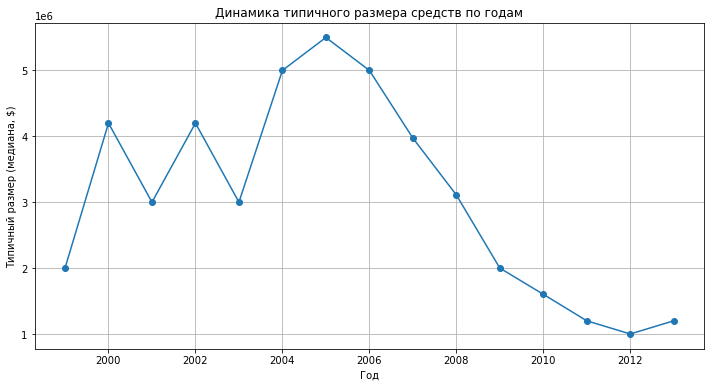

In [18]:
# построим график динамики типичного размера средств

plt.figure(figsize=(12,6))
plt.plot(funding_by_year['funded_year'], funding_by_year['typical_amount'], marker='o')
plt.title('Динамика типичного размера средств по годам')
plt.xlabel('Год')
plt.ylabel('Типичный размер (медиана, $)')
plt.grid(True)
plt.show()

#### Промежуточный вывод  

- **Максимальный типичный размер раунда** был в **2005 году** — медиана достигла **5,5 млн долларов**.  
- После 2006 года медианный размер начал снижаться и к 2012 году упал до **1 млн долларов**.  
- Одновременно количество раундов росло: с ~1600 в 2005 году до более 11 000 в 2013 году.  
- В **2013 году** наблюдается пик по числу раундов (11 072), при этом типичный размер одного раунда был относительно низким — около **1,2 млн долларов**.  

Можно сделать вывод, что рынок стал более массовым: число сделок росло, но средний чек инвестиций заметно снижался.  


### 2.2. Люди и их образование

**План работы:**
- В датасете `people.csv` содержатся сотрудники и `company_id`.  
- В датасете `education.csv` хранится информация об образовании (`person_id`), связанная с сотрудниками через `people.id`.  
- Для каждой компании можно посчитать:  
  - общее число сотрудников;  
  - число сотрудников, у которых есть хотя бы одна запись в `education`;  
  - долю сотрудников **без информации об образовании**.

**Группировка компаний по размеру:**  
- **1 сотрудник**,  
- **2 сотрудника**,  
- **3 сотрудника**,  
- **4–5 сотрудников**,  
- **6–10 сотрудников**,  
- **11–25 сотрудников**,  
- **26 и более сотрудников**.  

Такая классификация была выбрана на основе анализа распределения числа сотрудников по компаниям:  
- большинство компаний представлены одним сотрудником,  
- гораздо меньше — крупными коллективами.  

**Вопрос о присоединении `degrees.csv`:**  
- Таблица `degrees.csv` содержит дополнительные сведения (тип диплома, предмет).  
- Для оценки **полноты данных** достаточно факта наличия записи в `education`, поэтому для выполнения задачи присоединение `degrees.csv` не требуется.  


In [19]:
# Объединим данные people и education через person_id
people_education = people.merge(
    education,
    left_on='id', right_on='person_id',
    how='left' # «левое соединение», то есть мы берём всех сотрудников из people, даже если у них нет записей в education
)

In [20]:
# Для каждой компании считаем общее число сотрудников и число сотрудников с образованием
company_edu_stats = (
    people_education.groupby('company_id')
    .agg(
        total_employees=('id_x', 'count'),
        employees_with_edu=('instituition', lambda x: x.notna().sum())
    )
    .reset_index()
)

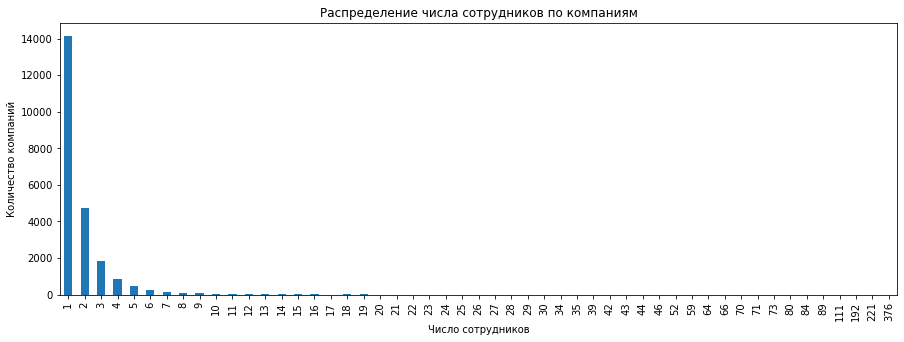

In [21]:
# Сначала визуализируем распределение числа сотрудников по компаниям
company_edu_stats['total_employees'].value_counts().sort_index().plot(
    kind='bar', figsize=(15,5)
)
plt.title('Распределение числа сотрудников по компаниям')
plt.xlabel('Число сотрудников')
plt.ylabel('Количество компаний')
plt.show()

In [22]:
# Создаем корзины по числу сотрудников, чтобы группы были более сбалансированы
bins = [0, 1, 2, 3, 5, 10, 25, float('inf')]
labels = ['1', '2', '3', '4-5', '6-10', '11-25', '26+']

company_edu_stats['company_size_bin'] = pd.cut(
    company_edu_stats['total_employees'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Проверим количество компаний в каждой корзине
company_edu_stats['company_size_bin'].value_counts().sort_index()

1        14150
2         4735
3         1857
4-5       1278
6-10       672
11-25      195
26+         35
Name: company_size_bin, dtype: int64

In [23]:
# Считаем долю сотрудников без информации об образовании для каждой компании
company_edu_stats['share_missing_info'] = 1 - (
    company_edu_stats['employees_with_edu'] / company_edu_stats['total_employees']
)

# Средняя доля по корзинам
grouped_share_missing_info = (
    company_edu_stats
    .groupby('company_size_bin')['share_missing_info']
    .mean()
    .reset_index()
)

# Выводим результат
display(grouped_share_missing_info)


,company_size_bin,share_missing_info
0,1,0.592862
1,2,0.227350
2,3,0.228325
3,4-5,0.276252
4,6-10,0.312232
5,11-25,0.306520
6,26+,0.204581


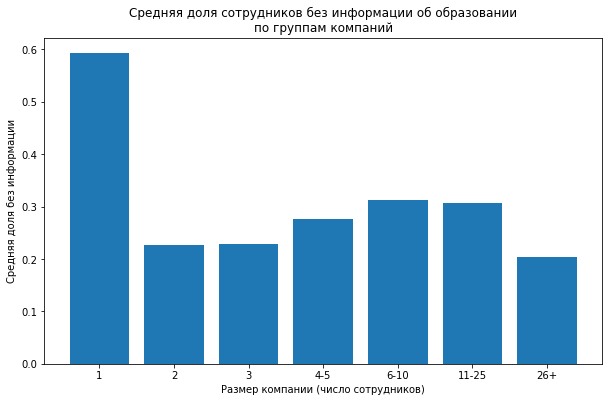

In [24]:
# Визуализация
plt.figure(figsize=(10,6))
plt.bar(grouped_share_missing_info['company_size_bin'], grouped_share_missing_info['share_missing_info'])
plt.title('Средняя доля сотрудников без информации об образовании\nпо группам компаний')
plt.xlabel('Размер компании (число сотрудников)')
plt.ylabel('Средняя доля без информации')
plt.show()

#### Промежуточный вывод: люди и их образование

Анализ полноты информации об образовании сотрудников в зависимости от размера компании показал следующие результаты:

- Для **компаний с одним сотрудником** доля отсутствующей информации об образовании наиболее высока — около **59%**.  
- В группах **2–3 сотрудников** ситуация заметно улучшается: доля снижается до **приблизительно 23%**.  
- В диапазоне **4–25 сотрудников** доля сотрудников без информации об образовании держится на уровне **27–31%**.  
- Для **крупных компаний (26+ сотрудников)** наблюдается наименьшая доля пропусков — около **20%**.  

**Вывод:** чем больше компания, тем полнее данные об образовании её сотрудников. Наибольшее количество пропусков характерно для компаний-«одиночек», тогда как по крупным компаниям сведения фиксировались значительно систематичнее.  

При этом для анализа полноты сведений о сотрудниках достаточно факта наличия записи в `education.csv`.  
Присоединение таблицы **`degrees.csv`** не требуется, так как она содержит лишь уточняющую информацию о типе диплома и предмете обучения, которая не влияет на оценку полноты данных.


### 2.3. Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных.

- Установим, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Нам необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.
- Оценим, можно ли использовать столбцы с именем `network_username` для объединения данных.

In [25]:
# Проверим, сколько уникальных значений network_username в каждом датасете
print("Уникальных network_username в people:", people['network_username'].nunique(dropna=True))
print("Уникальных network_username в company_and_rounds:", company_and_rounds['network_username'].nunique(dropna=True))

Уникальных network_username в people: 38421
Уникальных network_username в company_and_rounds: 79571


In [26]:
# Проверим пересечение значений между датасетами
common_usernames = set(people['network_username'].dropna()).intersection(
    set(company_and_rounds['network_username'].dropna())
)
print("Количество общих network_username между people и company_and_rounds:", len(common_usernames))

Количество общих network_username между people и company_and_rounds: 2199


In [27]:
# Проверим, есть ли дубли внутри каждого датасета
people_user_counts = people['network_username'].value_counts()
company_user_counts = company_and_rounds['network_username'].value_counts()

print("Количество network_username в people, встречающихся более 1 раза:", (people_user_counts > 1).sum())
print("Количество network_username в company_and_rounds, встречающихся более 1 раза:", (company_user_counts > 1).sum())

Количество network_username в people, встречающихся более 1 раза: 425
Количество network_username в company_and_rounds, встречающихся более 1 раза: 8409


**Вывод:** network_username не подходит для объединения, т.к. много дублирующихся значений или нет пересечений между таблицами.


### 2.4. Проблемный датасет и причина возникновения пропусков


In [28]:
# 1. Таблица с уникальными компаниями
company_columns = [
    'company_id_main', 'name', 'category_code', 'status',
    'founded_at', 'closed_at', 'country_code',
    'investment_rounds', 'funding_rounds', 'funding_total', 'milestones'
]

companies_clean = company_and_rounds[company_columns].drop_duplicates(
    subset=['company_id_main']
).reset_index(drop=True)

# 2. Таблица с раундами финансирования
rounds_columns = [
    'funding_round_id', 'company_id_round', 'funded_at',
    'funding_round_type', 'raised_amount', 'pre_money_valuation',
    'participants', 'is_first_round', 'is_last_round'
]

rounds_clean = company_and_rounds[rounds_columns].drop_duplicates().reset_index(drop=True)

# Проверим размеры
print("Уникальных компаний:", companies_clean.shape[0])
print("Количество строк в таблице раундов:", rounds_clean.shape[0])

Уникальных компаний: 196554
Количество строк в таблице раундов: 52929


#### Промежуточный вывод: проблемный датасет и причина возникновения пропусков

**Цель:** привести `company_and_rounds.csv` в вид, удобный для анализа по отдельным компаниям, сохранив данные о раундах финансирования.

Какие мы выполнили шаги:

**Разделение таблицы на две:**
   - `companies_clean` — характеристики компании (одна строка = одна компания).
   - `rounds_clean` — данные о раундах финансирования (связь через `company_id`).

**Очистка и упорядочивание столбцов:**
   - Оставлены только необходимые для анализа столбцы.
   - Названия упорядочены и логичны.
   - Типы данных приведены к подходящим: даты → `datetime`, числовые значения → `float`.

**Сохранение связности данных:**
   - Все раунды остались в `rounds_clean`.
   - В `companies_clean` учтены агрегированные показатели: количество раундов, сумма финансирования и другие ключевые характеристики.

**Результаты:**
   - `companies_clean`: 196 554 строки (по количеству уникальных компаний).  
   - `rounds_clean`: 52 929 строк (информация по отдельным раундам).  
   - Каждая компания занимает ровно одну строку, что позволяет фильтровать и агрегировать данные без ошибок и дублирования.

**Вывод:**  
   - Таблицы готовы к анализу: можно фильтровать компании по параметрам, рассчитывать показатели на одну компанию, соединять с другими датасетами через `company_id`.  
   - Пропуски сохранены, так как они отражают фактическое отсутствие информации и важны для анализа качества данных.  
   - Формат соответствует гипотезе заказчика: данные о компаниях и раундах теперь хранятся в максимально удобном виде для анализа.



## Шаг 3. Исследовательский анализ объединённых таблиц

> Приступите к шагу 3 после проверки ревьюера.

<big>Студентам нужно чётко сказать - проверять дальше или не проверять.</big>


### 3.1. Объединение данных

In [29]:
# Отбираем компании, которые интересуют заказчика
interested_companies = companies_clean[
    (companies_clean['funding_rounds'] > 0) |
    (companies_clean['investment_rounds'] > 0) |
    (companies_clean['status'] == 'acquired')
].copy()

# Проверка размера итоговой таблицы
print("Количество компаний в итоговом датасете:", interested_companies.shape[0])

# Проверяем структуру таблицы
interested_companies.info()

# Просмотр первых строк
interested_companies.head()

Количество компаний в итоговом датасете: 40747
<class 'pandas.core.frame.DataFrame'>
Int64Index: 40747 entries, 0 to 196552
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   company_id_main    40747 non-null  float64       
 1   name               40747 non-null  object        
 2   category_code      35315 non-null  object        
 3   status             40747 non-null  object        
 4   founded_at         27807 non-null  datetime64[ns]
 5   closed_at          2128 non-null   datetime64[ns]
 6   country_code       34742 non-null  object        
 7   investment_rounds  40747 non-null  float64       
 8   funding_rounds     40747 non-null  float64       
 9   funding_total      40747 non-null  float64       
 10  milestones         40747 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(4)
memory usage: 3.7+ MB


,company_id_main,name,category_code,status,founded_at,closed_at,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,USA,0.0,3.0,39750000.0,5.0
1,10.0,Flektor,games_video,acquired,NaT,NaT,USA,0.0,0.0,0.0,0.0
2,100.0,There,games_video,acquired,NaT,NaT,USA,0.0,0.0,0.0,4.0
13,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,USA,0.0,1.0,5000000.0,3.0
18,10014.0,Mobclix,mobile,acquired,2008-03-01,NaT,USA,0.0,1.0,0.0,4.0


#### Промежуточный вывод: объединение данных

- Количество компаний: 40 747 — примерно 40 000, как и ожидалось.
- Структура таблицы: каждая строка — отдельная компания.
- Столбцы: оставлены только нужные для дальнейшего анализа (company_id_main, name, category_code, status, founded_at, closed_at, country_code, investment_rounds, funding_rounds, funding_total, milestones).
- Типы данных корректны: даты — datetime64[ns], числовые значения — float64, текстовые — object.
- Пропуски сохранены, что важно для анализа качества данных (founded_at, closed_at, category_code, country_code).

Таким образом, теперь у нас есть чистый и фильтрованный датасет 40 000+ компаний, с которым можно безопасно работать для анализа интересующих заказчика вопросов.


### 3.2. Анализ выбросов


In [30]:
# 1. Проверим основные статистики
stats = interested_companies['funding_total'].describe()
print(stats)

count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+05
75%      5.650650e+06
max      5.700000e+09
Name: funding_total, dtype: float64


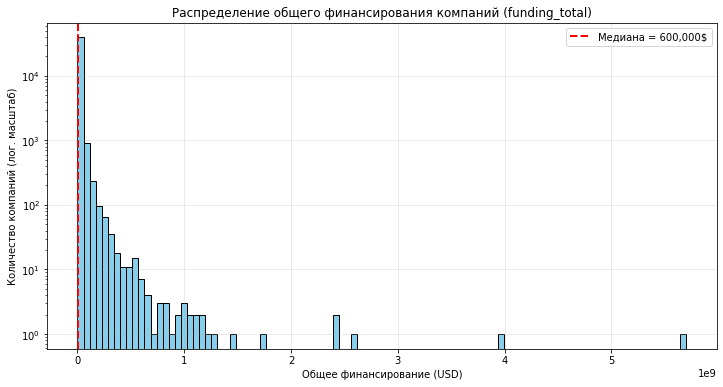

In [31]:
# Настроим размер графика
plt.figure(figsize=(12,6))

# Гистограмма для funding_total, используем логарифмическую шкалу, чтобы учесть большие выбросы
plt.hist(interested_companies['funding_total'] + 1, bins=100, color='skyblue', edgecolor='black', log=True)  
# +1 чтобы избежать log(0)

# Добавим вертикальную линию для медианы
median_value = interested_companies['funding_total'].median()
plt.axvline(median_value, color='red', linestyle='dashed', linewidth=2, label=f'Медиана = {median_value:,.0f}$')

# Настройки графика
plt.title('Распределение общего финансирования компаний (funding_total)')
plt.xlabel('Общее финансирование (USD)')
plt.ylabel('Количество компаний (лог. масштаб)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Промежуточный вывод: анализ выбросов по funding_total

Распределение общего объёма финансирования асимметрично: большинство компаний получили небольшие суммы, тогда как несколько компаний привлекли очень крупные инвестиции (миллиарды долларов).

Среднее значение (приблизительно 10,1 млн) сильно смещено в сторону крупных компаний и не отражает типичный уровень финансирования.

Медиана (приблизительно 0,6 млн) является более надёжной оценкой типичного размера финансирования для рассматриваемого периода.

Визуализация показала:
- большую концентрацию компаний с финансированием до нескольких миллионов долларов
- редкие выбросы с очень крупными суммами.

Для последующего анализа целесообразно использовать медиану как показатель типичного объёма финансирования, а экстремальные значения учитывать как выбросы или специальные случаи.

**Вывод:** обычный размер финансирования большинства компаний составляет сотни тысяч долларов, тогда как редкие крупные сделки создают «длинный хвост» распределения. Обычные методы вычисления среднего не применимы к таким сильно асимметричным данны. Медиана лучше отражает типичное значение.


### 3.3. Куплены забесплатно?

- Исследуем компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

- Рассчитаем аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажем, каким процентилям границы соответствуют.

In [32]:
# Объединяем interested_companies с таблицей acquisition
# В acquisition используется acquired_company_id для идентификации купленной компании
merged_acq = interested_companies.merge(
    acquisition[['acquired_company_id', 'price_amount']],
    left_on='company_id_main',       # в interested_companies
    right_on='acquired_company_id',  # в acquisition
    how='left'
)

# Фильтруем компании, проданные "за бесплатно" или за $1, и при этом с ненулевым финансированием
free_or_one_dollar = merged_acq[
    (merged_acq['price_amount'].between(0, 1)) & 
    (merged_acq['funding_total'] > 0)
].copy()

# Проверим размер выборки
print("Количество компаний с price_amount 0 или 1 и ненулевым финансированием:", free_or_one_dollar.shape[0])

# Рассчитаем аналитические границы выбросов для funding_total (используем межквартильный размах)
Q1 = interested_companies['funding_total'].quantile(0.25)
Q3 = interested_companies['funding_total'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Определим процентиль для границ
lower_percentile = (interested_companies['funding_total'] <= lower_bound).mean() * 100
upper_percentile = (interested_companies['funding_total'] >= upper_bound).mean() * 100

# Выведем результаты
print(f"Нижняя граница выбросов: {lower_bound:.2f}, соответствует примерно {lower_percentile:.2f}%")
print(f"Верхняя граница выбросов: {upper_bound:.2f}, соответствует примерно {upper_percentile:.2f}%")


Количество компаний с price_amount 0 или 1 и ненулевым финансированием: 1618
Нижняя граница выбросов: -8475975.00, соответствует примерно 0.00%
Верхняя граница выбросов: 14126625.00, соответствует примерно 14.38%


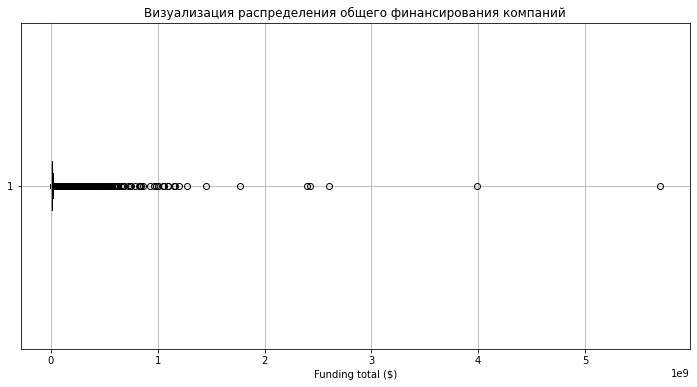

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.boxplot(interested_companies['funding_total'], vert=False, showfliers=True)
plt.title('Визуализация распределения общего финансирования компаний')
plt.xlabel('Funding total ($)')
plt.grid(True)
plt.show()

#### Промежуточный вывод: компании с нулевым или минимальным финансированием

**Количество компаний**, проданных за 0 или 1 доллар при ненулевом финансировании: **1 618**.

Аналитические границы выбросов** для столбца `funding_total` (межквартильный размах):
  - Нижняя граница: **-8 475 975**, соответствует примерно **0.00%** компаний.
  - Верхняя граница: **14 126 625**, соответствует примерно **14.38%** компаний.

**Выводы:**

- Отрицательное значение нижней границы выбросов не имеет практического смысла в контексте финансирования и связано только с использованием метода межквартильного размаха. Фактически, финансирование не может быть отрицательным.
- Верхняя граница показывает, что около 14% компаний имеют аномально высокий уровень финансирования по сравнению с типичным диапазоном.
- Метод межквартильного размаха применим, но стоит учитывать, что распределение `funding_total` сильно скошено вправо, поэтому обычные меры типа среднего и стандартного отклонения менее информативны.



### 3.4. Цены стартапов по категориям


In [34]:
# Объединяем acquisition с интересующими компаниями 
acq_merged = acquisition.merge(
    interested_companies[['company_id_main', 'category_code']],
    left_on='acquired_company_id',
    right_on='company_id_main',
    how='left'
)

# Оставляем только сделки с известной ценой > 0
acq_nonzero = acq_merged[acq_merged['price_amount'].notna() & (acq_merged['price_amount'] > 0)].copy()

# Убираем верхние выбросы: исключаем всё, что выше 90-го перцентиля
q90 = acq_nonzero['price_amount'].quantile(0.90)
acq_trim = acq_nonzero[acq_nonzero['price_amount'] <= q90].copy()

print(f"Всего сделок с ценой >0: {len(acq_nonzero)}")
print(f"Оставлено после отсечения >90%: {len(acq_trim)} (90%-перцентиль = {q90:.0f})\n")

# Агрегируем по category_code: медиана, std, количество
category_stats = (
    acq_trim
    .groupby('category_code')['price_amount']
    .agg(median_price='median', std_price='std', count='count')
    .reset_index()
)

# Берём репрезентативные категории (не менее 5 сделок)
category_stats = category_stats[category_stats['count'] >= 5].copy()

# Сортируем по медиане (убывание) и показываем топ-10
top_categories = category_stats.sort_values(by=['median_price', 'std_price'], ascending=False).head(10)
display(top_categories)

Всего сделок с ценой >0: 2476
Оставлено после отсечения >90%: 2228 (90%-перцентиль = 792500000)



,category_code,median_price,std_price,count
4,cleantech,162500000.0,1.444089e+08,34
29,security,148500000.0,2.149933e+08,31
10,finance,131500000.0,1.912827e+08,16
3,biotech,120750000.0,2.138114e+08,226
13,health,115000000.0,1.552634e+08,8
6,ecommerce,105000000.0,1.800376e+08,46
18,messaging,100000000.0,6.907460e+07,5
16,manufacturing,97200000.0,2.176823e+08,14
30,semiconductor,75000000.0,1.350668e+08,64
28,search,72500000.0,1.293638e+08,17


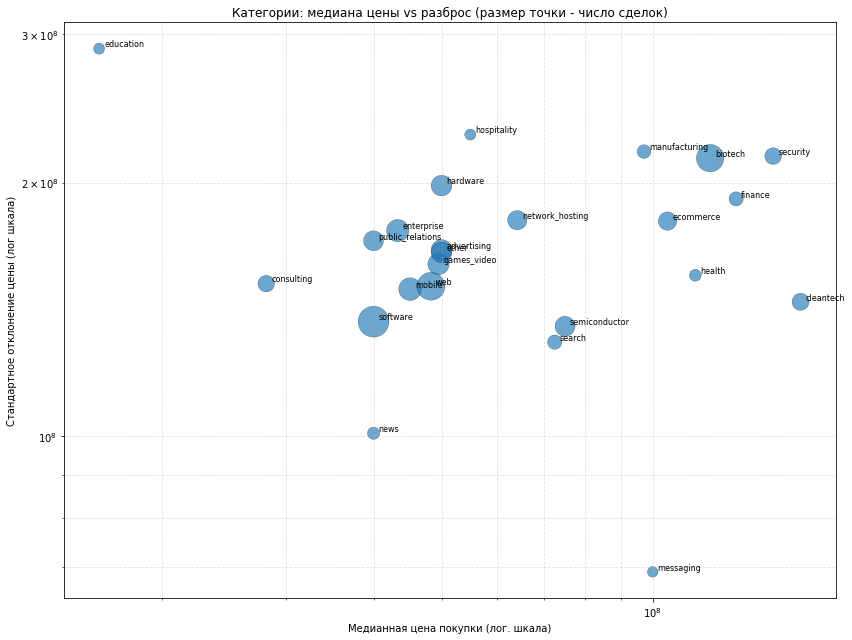

In [35]:
# Визуализация: scatter (median и std)

plt.figure(figsize=(12,9))

x = category_stats['median_price']
y = category_stats['std_price'].fillna(0)
sizes = (category_stats['count'] ** 0.5) * 50  # масштабируем размер точки

plt.scatter(x, y, s=sizes, alpha=0.65, edgecolor='k', linewidth=0.3)

# Построим логарифмические оси, т.к. диапазон величин очень большой
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Медианная цена покупки (лог. шкала)')
plt.ylabel('Стандартное отклонение цены (лог шкала)')
plt.title('Категории: медиана цены vs разброс (размер точки - число сделок)')

# Подписи категорий рядом с точками
for _, row in category_stats.iterrows():
    # если std_nan, подставим небольшое значение для корректного размещения на лог шкале
    y_val = row['std_price'] if pd.notna(row['std_price']) and row['std_price'] > 0 else max(1.0, row['median_price']*0.1)
    plt.annotate(
        row['category_code'],
        (row['median_price'], y_val),
        textcoords="offset points", xytext=(5,2), fontsize=8
    )

plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

#### Промежуточный вывод: Цены стартапов по категориям

- Рассчитали **типичные цены покупки стартапов** (медиана) и **разброс цен** (стандартное отклонение) для категорий стартапов с хотя бы 5 сделками.
- Топ-10 категорий с самыми высокими медианными ценами и значительным разбросом

При подготовке данных:
исключили сделки с price_amount = 0, чтобы убрать «фиктивные» покупки и пропуски в цене,
отсекли верхние 10% значений (выше 90-го перцентиля), чтобы убрать экстремальные выбросы, искажавшие картину.

**Почему топ-10 категорий:**  
  Выбор десяти категорий позволяет одновременно показать **категории с высокими типичными ценами** и **категории с наибольшим разбросом цен**, при этом не перегружая таблицу или график. Это число достаточно большое, чтобы выявить закономерности, и достаточно маленькое, чтобы результаты оставались наглядными.

**Почему рассчитывали медиану и стандартное отклонение:**  
  - **Медиана** показывает **типичную цену покупки стартапа** и устойчива к выбросам, которые в нашем датасете очень большие (максимальные сделки достигают миллиардов).  
  - **Стандартное отклонение** показывает **разброс цен** и помогает выявить категории с высокой вариативностью сделок — это важно для оценки инвестиционного риска.  

Таким образом, топ-10 категорий отражает как **характерные высокие цены**, так и **значительный разброс**, что соответствует интересам крупных инвесторов, готовых к риску ради потенциально больших доходов.

**Результаты:**

**Категории с высокими медианными ценами:**
cleantech, security, finance, biotech, health — сделки здесь обычно крупные, медианные значения превышают 100 млн долларов.
Это делает их особенно привлекательными для крупных инвесторов, готовых вкладываться в дорогие сделки.

**Категории со значительной вариативностью цен:**
У таких отраслей, как biotech, ecommerce, manufacturing, разброс цен очень высок, что указывает на наличие как дорогих, так и сравнительно дешёвых сделок.
Это повышает риск, но даёт возможность для крупных выигрышей.

**Вывод**
После очистки данных мы получили более реалистичную картину:
категории вроде cleantech, security и finance характеризуются высокими типичными ценами сделок,
а отрасли вроде biotech и ecommerce дополнительно выделяются высокой вариативностью, что важно учитывать при оценке инвестиционного риска.
Таким образом, именно эти категории стартапов могут представлять наибольший интерес для инвесторов, готовых к высоким вложениям и рискам.




### 3.5. Сколько раундов продержится стартап перед покупкой


In [36]:
# Посмотрим на распределение значений в столбце funding_rounds
interested_companies['funding_rounds'].describe()

# Дополнительно можно посмотреть уникальные значения и их количество
interested_companies['funding_rounds'].value_counts().sort_index()

0.0      9040
1.0     20534
2.0      6142
3.0      2662
4.0      1216
5.0       600
6.0       249
7.0       147
8.0        67
9.0        46
10.0       23
11.0       10
12.0        3
13.0        5
14.0        1
15.0        2
Name: funding_rounds, dtype: int64

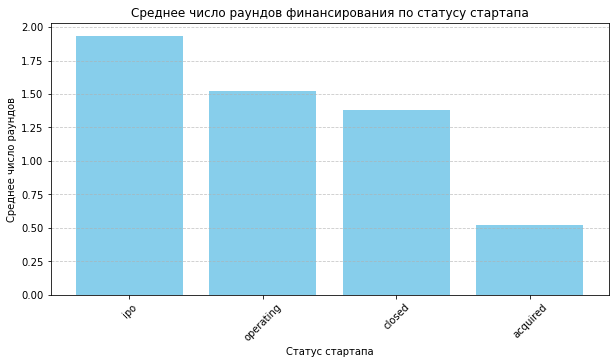

In [37]:
# Рассчитаем среднее число раундов для каждого статуса
mean_rounds_by_status = interested_companies.groupby('status')['funding_rounds'].mean().sort_values(ascending=False)

# Построим график
plt.figure(figsize=(10,5))
plt.bar(mean_rounds_by_status.index, mean_rounds_by_status.values, color='skyblue')
plt.title('Среднее число раундов финансирования по статусу стартапа')
plt.xlabel('Статус стартапа')
plt.ylabel('Среднее число раундов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

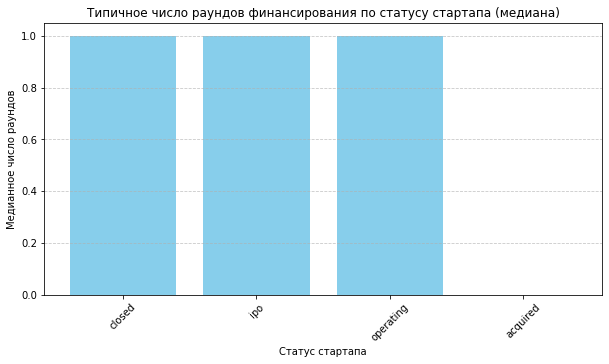

In [38]:
# Рассчитаем медианное число раундов для каждого статуса
median_rounds_by_status = interested_companies.groupby('status')['funding_rounds'].median().sort_values(ascending=False)

# Построим график
plt.figure(figsize=(10,5))
plt.bar(median_rounds_by_status.index, median_rounds_by_status.values, color='skyblue')
plt.title('Типичное число раундов финансирования по статусу стартапа (медиана)')
plt.xlabel('Статус стартапа')
plt.ylabel('Медианное число раундов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Промежуточный вывод: анализ количества раундов финансирования у стартапов

Большинство стартапов имеют **0–1 раунд финансирования**:  
  - 0 раундов — 9 040 компаний  
  - 1 раунд — 20 534 компаний  
  
На втором месте идут стартапы с **2–3 раундами**, количество постепенно снижается с увеличением числа раундов.

Небольшое число стартапов прошло более 10 раундов — это редкие случаи.

Из этого следует, что **типичное количество раундов финансирования** для стартапов — **1 раунд**, а значения больше 5–6 уже считаются выбросами.

Для дальнейшего анализа по статусу стартапа удобно использовать среднее или медиану числа раундов в каждой группе, чтобы понять, сколько раундов в среднем проходит стартап до приобретения, закрытия или продолжения работы.



## Шаг 4. Итоговый вывод и рекомендации

**Предобработка и проверка данных**
- Все названия колонок приведены к единому формату: пробелы заменены на `_`, все буквы в нижнем регистре.
- В `company_and_rounds` обнаружен дубликат столбца `company_id`:
  - `company_id_main` — основной идентификатор компании
  - `company_id_round` — идентификатор для раундов финансирования
- Типы данных приведены к корректным:
  - даты → `datetime`
  - числовые значения → `float`
  - категориальные столбцы — `object`
- Особенности датасета `company_and_rounds`:
  - "Висящие" раунды (`company_id_main = NaN`) не имеют информации о компании — их нужно обрабатывать отдельно или игнорировать.
  - Пропуски в ключевых колонках (`founded_at`, `closed_at`, `country_code`) требуют внимательного учета при агрегировании.
- Вывод: данные приведены к единому формату и готовы для анализа.

**Анализ пропусков**
- `acquisition.csv` — данные в целом полные; пропуски в `term_code` (~80%) не мешают основному анализу.
- `company_and_rounds.csv` — детальные данные по раундам заполнены лишь в ~25% случаев, базовая информация о компаниях есть почти у всех.
- `people.csv` — большое количество пропусков в `company_id` (~85%) и `network_username` (~83%).
- `education.csv` — пропуски в `graduated_at` (~47%), данные об учебных заведениях почти полные.
- `degrees.csv` — пропуски в `degree_type` (~10%) и `subject` (~26%), в целом достаточно для анализа уровня образования.

**Приведение company_and_rounds к удобному виду**
- Разделение таблицы на:
  - `companies_clean` — одна строка = одна компания
  - `rounds_clean` — информация по раундам финансирования
- Сохранены ключевые показатели: количество раундов, сумма финансирования, milestones.
- Результаты:
  - `companies_clean`: 196 554 строки
  - `rounds_clean`: 52 929 строк
- Вывод: таблицы готовы к фильтрации, агрегированию и объединению с другими данными.

**Объединение данных**
- Отобраны компании с интересующими параметрами:
  - `funding_rounds > 0` или `investment_rounds > 0` или `status == acquired`
- Итоговый датасет: 40 747 компаний
- Структура корректна, пропуски сохранены для анализа качества данных.
- Вывод: готовый датасет для анализа инвестиционной активности и сделок.

**Анализ выбросов по funding_total**
- Распределение сильно скошено вправо:
  - Среднее: ~10,1 млн долларов
  - Медиана: ~0,6 млн долларов (типичный размер)
- Большинство компаний привлекло небольшие суммы, редкие сделки достигают миллиардов.
- Вывод: для анализа типичного финансирования медиана более информативна, экстремальные значения учитывать как выбросы.

**Компании с минимальной стоимостью покупки**
- Проданы за 0 или 1 доллар при ненулевом финансировании: 1 618 компаний
- Верхняя граница выбросов: 14,1 млн долларов (~14,4% компаний)
- Нижняя граница выбросов отрицательная из-за метода межквартильного размаха — фактически финансирование не может быть отрицательным.
- Вывод: редкие сделки с аномально высокой суммой финансирования; метод межквартильного размаха применим, но распределение сильно скошено.

**Цены стартапов по категориям**
Для категорий с ≥5 сделками рассчитаны медиана и разброс цен.  
Чтобы убрать искажения, исключены нулевые цены и сделки выше 90-го перцентиля.  

*Результаты:*
- Высокие медианы: *cleantech (162 млн)*, *security (149 млн)*, *finance (132 млн)*, *biotech (121 млн)*, *health (115 млн)*.  
- Значительный разброс: *biotech*, *ecommerce*, *manufacturing*.  

*Вывод:* 
Интерес для инвесторов представляют категории с высокими медианами и большим разбросом — сделки там дорогие, но рискованные.  


**Анализ количества раундов финансирования**
- Большинство стартапов имеют 0–1 раунд:
  - 0 раундов — 9 040 компаний
  - 1 раунд — 20 534 компаний
- Редкие стартапы прошли >10 раундов.
- Типичное количество раундов: 1
- Вывод: для анализа по статусу стартапа удобно использовать медиану числа раундов, экстремальные значения учитывать как редкие случаи.

**Общие выводы**
- Данные приведены к единому формату, пропуски сохранены, что позволяет анализировать средние тенденции.
- Финансирование большинства компаний составляет сотни тысяч долларов, редкие сделки создают длинный хвост распределения.
- Категории с высокими медианными ценами и большим разбросом могут привлекать крупных инвесторов.
- Большинство стартапов проходит 0–1 раунд финансирования, а количество раундов до покупки или закрытия растёт постепенно.
- Информация о людях и их образовании частично пропущена, но позволяет выявлять общие тенденции.

**Рекомендации для дальнейшего анализа:**
1. Для типичных значений использовать медиану вместо среднего.
2. При анализе раундов финансирования учитывать редкие аномальные значения.
3. При объединении данных учитывать «висящие» раунды и пропуски.
4. Все выводы относятся к средним тенденциям, а не к каждой отдельной компании или сотруднику.
